In [ ]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

include(joinpath(@__DIR__, "..", "src", "SADflow.jl"))
using .SADflow
using ADerrors, FormalSeries
using Flux
using ArgParse
using Random

  Activating project at `c:\Users\louis\OneDrive\Desktop\MasterThesis\GitHub`


In [2]:


config = TrainingConfig(
    0.24,
    0.0,
    100,
    32,
    128,
    1.0e-3,
    0.7,
    4,
    1,
    "tanh",
    1234,
    0.0,       # weight_decay
    100,       # N_eval
    8,         # L1
    8,         # L2
    8,         # B
    joinpath(@__DIR__, "..", "priors"),
    "none",
)

Random.seed!(config.seed)
rng = MersenneTwister(config.seed)

space = Grid{2}((8, 8 ), (8, 8))
params_phi4 = Phi4Params(config.kappa, config.lambda)

plots_dir  = joinpath(config.output_dir, "plots")
models_dir = joinpath(config.output_dir, "models")
mkpath(plots_dir); mkpath(models_dir)

run_tag = "2d_l$(config.lambda)_k$(config.kappa)_L_$(config.L1)_$(config.L2)_nodes$(config.nodes)_bs$(config.batchsize)_activation$(config.activation)_lr$(config.lrate)"

model_path = joinpath(models_dir, "$(run_tag).bson")
metadata_path = joinpath(models_dir, "$(run_tag)_metadata.jld2")

"none\\models\\2d_l0.0_k0.24_L_8_8_nodes4_bs32_activationtanh_lr0.001_metadata.jld2"

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


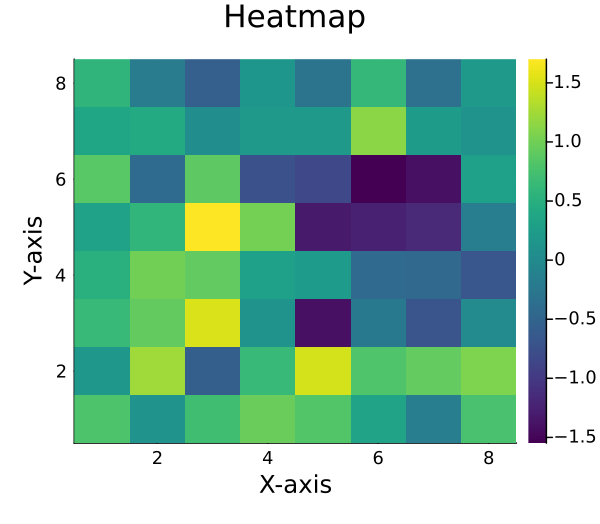

In [3]:
data_file = joinpath(
    config.priors_dir,
    "2d_l$(config.lambda)_k$(config.kappa)_L_$(config.L1)_$(config.L2).jld2",
)

metadata = build_run_metadata(
    config;
    data_file=data_file,
    run_tag=run_tag,   
)

pics = load_prior_data(data_file)

var_z = estimate_source_variance(pics)

prior, prior_test, train_indices, test_indices =
    split_data(pics, config.split; rng=rng)


build_heatmap_example(prior, config)


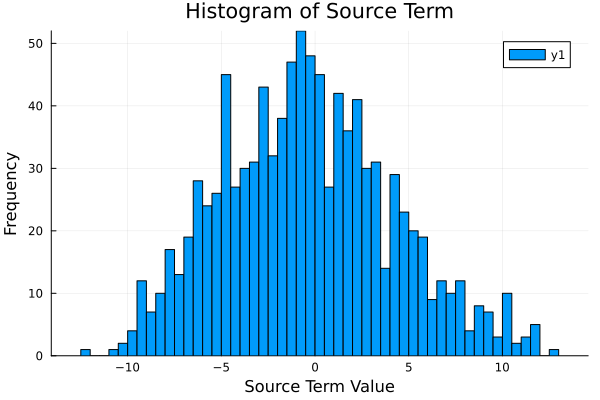

In [11]:
using Plots

ϵ = Series{Float64,2}((0.0,1.0))
N_corr = 1000

PHI =  Array{Series{Float64,2},4}(undef, config.L1, config.L2 ,1, N_corr)
for n in 1:N_corr
    for i in 1:config.L1
        for j in 1:config.L2
            PHI[i,j,1,n] = Series{Float64,2}((pics[i,j,1,n], 0.0))
        end
    end
end

source_term = sum(PHI[1,:,1,:], dims=1)[1,:]
WT_pre = exp.(  ϵ .* source_term )

WTs_pre = []

for n in 1:N_corr
    push!(WTs_pre, (WT_pre[n])[2])
end
histogram(WTs_pre , bins=50, title="Histogram of Source Term", xlabel="Source Term Value", ylabel="Frequency")


In [5]:
function make_CNN(space::Grid, params::Phi4Params{T}; nodes=16, activation=tanh) where T

    vol = space.iL
    Nₜ = vol[1]
    Nₓ = prod(vol[2:end])

    conv_branch = Chain(
        PeriodicConv((3, 3), 1 => nodes; σ=activation, bias=false),
        PeriodicConv((3, 3), nodes => nodes; σ=activation, bias=false),
        PeriodicConv((3, 3), nodes => 1; σ=identity),
    ) |> Flux.f64

    return Chain(x -> conv_branch(x),
                x -> exp.(x))
end

activ = activation_fn(config.activation)
model = make_CNN(
    space, 
    params_phi4; 
    nodes=config.nodes, 
    activation=activ)

loss_function = KLloss_batch

optimiser = OptimiserChain(WeightDecay(config.weight_decay), Flux.Adam(config.lrate))
opt = Flux.setup(optimiser, model)

(layers = ((conv_branch = (layers = ((conv = (σ = (), weight = Leaf(OptimiserChain(WeightDecay(lambda=0.0), Adam(eta=0.001, beta=(0.9, 0.999), epsilon=1.0e-8)), (nothing, ([0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0], [0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0], (0.9, 0.999)))), bias = (), stride = ((), ()), pad = ((), (), (), ()), dilation = ((), ()), groups = ()),), (conv = (σ = (), weight = Leaf(OptimiserChain(WeightDecay(lambda=0.0), Adam(eta=0.001, beta=(0.9, 0.999), epsilon=1.0e-8)), (nothing, ([0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;; 0.0

In [6]:
fval = zeros(Float64, config.epochs)
ftest = zeros(Float64, config.epochs)
wESS  = zeros(Float64, config.epochs)
correlators_trw = Vector{Vector{ADerrors.uwreal}}(undef, config.epochs)

for epoch in 1:config.epochs
    train_epoch!(model, opt, prior, config.batchsize, var_z, params_phi4;
                 loss_function=loss_function, K=20, rng=rng)

    if epoch % 2 == 1
        train_loss, test_loss = evaluate_losses(model, prior, prior_test, config.test_batchsize,
                                                var_z, params_phi4;
                                                loss_function=loss_function, K=10,
                                                rng=rng)
        fval[epoch] = train_loss
        ftest[epoch] = test_loss

        println("Epoch $epoch | Train Loss: $(fval[epoch])")
        println("Epoch $epoch | Test Loss:  $(ftest[epoch])")
    end

    if epoch % 10== 9
        rw = evaluate_reweighting_checkpoint(model, prior_test, params_phi4;
                                             N=config.N_eval, tag=string(epoch), trace_samples=10,
                                             rng=rng)
        wESS[epoch] = rw.ess
        correlators_trw[epoch] = rw.corr
        println("Epoch $epoch | Test ESS: $(rw.ess)")
    end
end

┌ Warning: `ForwardDiff.derivative(f, x)` within Zygote cannot track gradients with respect to `f`,
│ and `f` appears to be a closure, or a struct with fields (according to `issingletontype(typeof(f))`).
│ typeof(f) = Main.LamPhi4_trw.var"#vjjv##0#vjjv##1"{ModelWrapper, Array{Float64, 4}, Array{Float64, 4}}
└ @ Zygote C:\Users\louis\.julia\packages\Zygote\55SqB\src\lib\forward.jl:158
┌ Warning: `ForwardDiff.derivative(f, x)` within Zygote cannot track gradients with respect to `f`,
│ and `f` appears to be a closure, or a struct with fields (according to `issingletontype(typeof(f))`).
│ typeof(f) = Main.LamPhi4_trw.var"#vjjv##2#vjjv##3"{ModelWrapper, Array{Float64, 4}, Array{Float64, 4}}
└ @ Zygote C:\Users\louis\.julia\packages\Zygote\55SqB\src\lib\forward.jl:158


Epoch 1 | Train Loss: 10.3247206800866
Epoch 1 | Test Loss:  10.369251490096945
Epoch 3 | Train Loss: 6.360960422455577
Epoch 3 | Test Loss:  6.312557639762984
Epoch 5 | Train Loss: 5.703082686042714
Epoch 5 | Test Loss:  5.7175836450196424
Epoch 7 | Train Loss: 5.472485070334248
Epoch 7 | Test Loss:  5.435717288321358
Epoch 9 | Train Loss: 5.262918400564577
Epoch 9 | Test Loss:  5.3146547922325595
Epoch 9 | Test ESS: 0.4733414647915596
Epoch 11 | Train Loss: 5.1764966293524415
Epoch 11 | Test Loss:  5.208459033028835
Epoch 13 | Train Loss: 5.130000774481845
Epoch 13 | Test Loss:  5.121857792833671
Epoch 15 | Train Loss: 4.994890339322578
Epoch 15 | Test Loss:  4.985310688619981
Epoch 17 | Train Loss: 4.90294532724034
Epoch 17 | Test Loss:  4.967904693504403
Epoch 19 | Train Loss: 4.8001560148300335
Epoch 19 | Test Loss:  4.846536567428646
Epoch 19 | Test ESS: 0.4912856445256538
Epoch 21 | Train Loss: 4.700033772401859
Epoch 21 | Test Loss:  4.794865158442876
Epoch 23 | Train Loss: 4.6

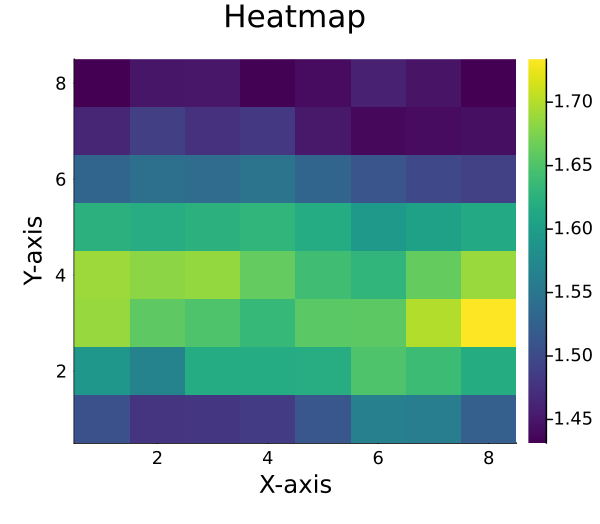

In [7]:

f = model(pics)

build_heatmap_example(f, config)

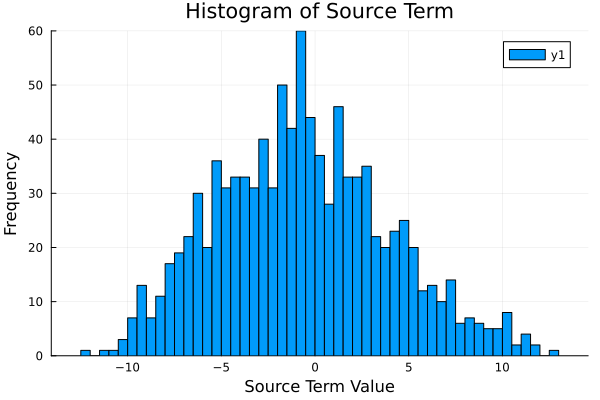

In [8]:

f = model(pics)

PHIT =  Array{Series{Float64,2},4}(undef, config.L1, config.L2 ,1, N_corr)
for n in 1:N_corr
    for i in 1:config.L1
        for j in 1:config.L2
            PHIT[i,j,1,n] = Series{Float64,2}((pics[i,j,1,n], f[i,j,1,n]))
        end
    end
end
#PHIT_T = sum(PHIT, dims=2)[:,1,:]


action_term = action(PHI,params_phi4) .- action(PHIT,params_phi4)
source_term = sum(PHIT[1,:,1,:], dims=1)[1,:]
WT_post = exp.(action_term .+  ϵ .* source_term )



WTs_post = []

for n in 1:N_corr
    push!(WTs_post, (WT_post[n])[2])
end
histogram(WTs_post , bins=50, title="Histogram of Source Term", xlabel="Source Term Value", ylabel="Frequency")

UndefVarError: UndefVarError: `WTs_pre` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

UndefVarError: UndefVarError: `max_epochs` not defined in `Main`
Suggestion: check for spelling errors or missing imports.